# Position of quasar

In [33]:
import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats
import numpy as np
from matplotlib import pyplot as plt
import math

Generate fake measurements

In [45]:
N=10
mu=1
sigma=0.2
xi=np.random.normal(loc=mu, scale=sigma, size=N)

#plt.hist(xi,bins=50,histtype='step', density=True)

Plot the individual likelihoods separately

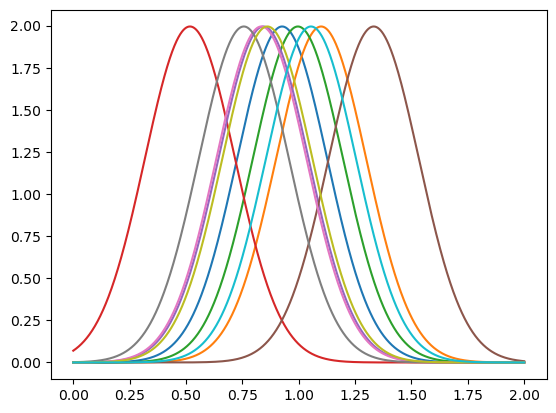

In [46]:
xplot = np.linspace(0, 2, 1000)

for i in range (0,10):
    dist = norm(xi[i], sigma)
    plt.plot(xplot, dist.pdf(xplot))

p=[]
for i in range (0,N):
    dist = norm(xi[0], sigma)
    p.append(dist.pdf(xplot))

Compute and plot the lnL of the dataset (likelihood=product of the likelihoods)

Text(0.5, 1.0, 'Loglikelihood')

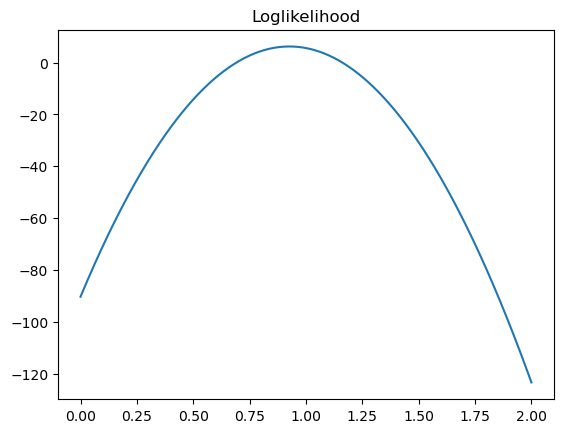

In [51]:
lnL=np.zeros(1000)
lnL[0]=0
for i in range (0,1000):
    for j in range (1,N):
        lnL[i]=lnL[i] + np.log(p[j][i])
        
plt.plot(xplot, lnL)
plt.title('Loglikelihood')

Text(0.5, 1.0, 'Likelihood')

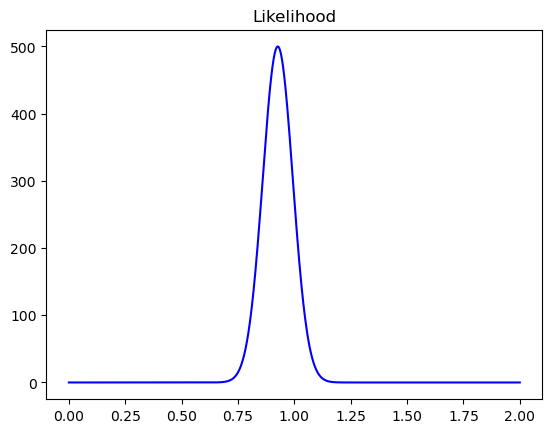

In [54]:
plt.plot(xplot, ((math.e)**lnL), color="blue")
plt.title('Likelihood')

Find the maximum of the lnL

In [55]:
max=xplot[lnL.argmax()]
max

0.9269269269269269

Compare the max of the lnL with the MLE estimator

In [56]:
mean=np.mean(xi)
mean

0.9222290462052776

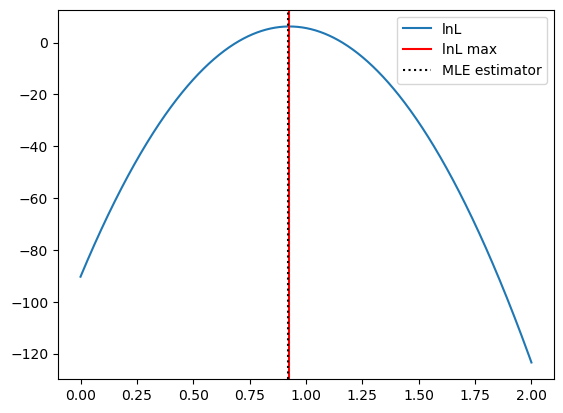

In [57]:
plt.plot(xplot, lnL, label='lnL' )
plt.axvline(max,c='red', label='lnL max')
plt.axvline(mean,c='black',ls='dotted', label='MLE estimator')
plt.legend()

Compute the Fisher matrix error

In [58]:
delta_theta=np.diff(xplot, n=1)
delta_theta=np.delete(delta_theta, 998)
corr_matrix=np.sqrt((-np.diff(lnL, n=2)/(delta_theta**2)))**(-1)
corr_matrix[0]

0.06666666666491812

Compare it with the estimator

In [59]:
sigma_mu=sigma/np.sqrt(N)
sigma_mu

0.06324555320336758

Plot the "measured" likelihood and the numerical likelihood distribution

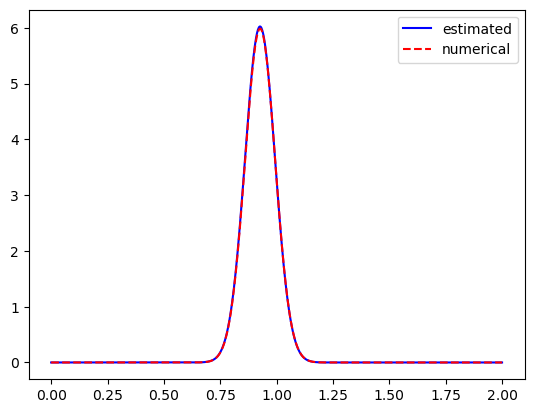

In [62]:
distG=scipy.stats.norm(loc=max, scale=corr_matrix[0])
plt.plot(xplot, ((math.e)**lnL)/83, color="blue", label='estimated')
plt.plot(xplot, distG.pdf(xplot), color="red", linestyle="dashed", label='numerical')

plt.legend()

#plt.xlim(0.75,1.25)